### Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline   # ✅ THIS fixes your error

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)



### Load preprocessed Data

In [6]:
df = pd.read_csv("../data/processed/fraud_baseline_model_data.csv")

print(df.shape)
df.head()

(6362620, 15)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff,high_amount,log_amount,amount_to_balance_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0,9.194276,0.057834,0,0,1,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0,7.531166,0.087731,0,0,1,0
2,1,181.00,181.0,0.00,0.0,0.0,1,181.00,0,5.204007,0.994505,0,0,0,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,181.00,0,5.204007,0.994505,1,0,0,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0,9.364703,0.280788,0,0,1,0


### Define X, Y

In [24]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

print("Target distribution:")
print(y.value_counts(normalize=True))

Target distribution:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


### Train, Test Split

In [3]:
# Train-test split with stratification because fraud is imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5090096, 14)
X_test: (1272524, 14)


### Baseline model — Logistic Regression

In [12]:
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

### Evaluate Logistic Regression

In [13]:
print("Logistic Regression Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
----------------------------------------
Accuracy : 0.9453707749323392
Precision: 0.022242869611735227
Recall   : 0.9616555082166768
F1-score : 0.0434800555884255
ROC-AUC  : 0.991686607461084

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.96      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



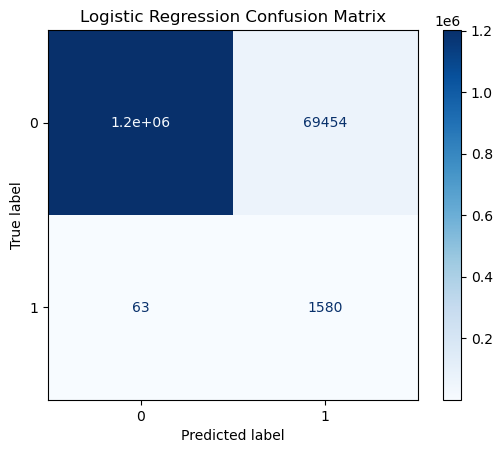

In [14]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

For fraud detection, I focused more on recall and precision than overall accuracy, because missing fraud is costly.

### Decision Tree

In [15]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=6,
    min_samples_split=20
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1-score :", f1_score(y_test, y_pred_tree))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tree))

Decision Tree Results
----------------------------------------
Accuracy : 0.9998601205163911
Precision: 0.9044726670347875
Recall   : 0.996956786366403
F1-score : 0.9484655471916619
ROC-AUC  : 0.999556763160241


### Random Forests

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
# Get probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]


y_pred_default = (y_probs >= 0.5).astype(int)


threshold = 0.3
y_pred_custom = (y_probs >= threshold).astype(int)


# DEFAULT RESULTS

print("Random Forest (Default Threshold = 0.5)")
print("-" * 50)
print("Accuracy :", accuracy_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("Recall   :", recall_score(y_test, y_pred_default))
print("F1-score :", f1_score(y_test, y_pred_default))
print("ROC-AUC  :", roc_auc_score(y_test, y_probs))


# CUSTOM RESULTS

print("\nRandom Forest (Custom Threshold = 0.3)")
print("-" * 50)
print("Accuracy :", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall   :", recall_score(y_test, y_pred_custom))
print("F1-score :", f1_score(y_test, y_pred_custom))
print("ROC-AUC  :", roc_auc_score(y_test, y_probs))

Random Forest (Default Threshold = 0.5)
--------------------------------------------------
Accuracy : 0.9999968566408177
Precision: 1.0
Recall   : 0.9975654290931223
F1-score : 0.9987812309567337
ROC-AUC  : 0.9987820344886549

Random Forest (Custom Threshold = 0.3)
--------------------------------------------------
Accuracy : 0.9999960708010223
Precision: 0.999390243902439
Recall   : 0.9975654290931223
F1-score : 0.9984770027413951
ROC-AUC  : 0.9987820344886549


### Compare Models

In [30]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest (0.5)',
        'Random Forest (0.3)'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_default),
        accuracy_score(y_test, y_pred_custom)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_tree, zero_division=0),
        precision_score(y_test, y_pred_default, zero_division=0),
        precision_score(y_test, y_pred_custom, zero_division=0)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_tree, zero_division=0),
        recall_score(y_test, y_pred_default, zero_division=0),
        recall_score(y_test, y_pred_custom, zero_division=0)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_tree, zero_division=0),
        f1_score(y_test, y_pred_default, zero_division=0),
        f1_score(y_test, y_pred_custom, zero_division=0)
    ],
    
    'ROC AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_probs),
        roc_auc_score(y_test, y_probs)
    ]
})

# Sort by Recall (important for fraud detection)
results = results.sort_values(by='Recall', ascending=False)

print(results)


                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2  Random Forest (0.5)  0.999997   1.000000  0.997565  0.998781  0.998782
3  Random Forest (0.3)  0.999996   0.999390  0.997565  0.998477  0.998782
1        Decision Tree  0.999860   0.904473  0.996957  0.948466  0.999557
0  Logistic Regression  0.945371   0.022243  0.961656  0.043480  0.991687


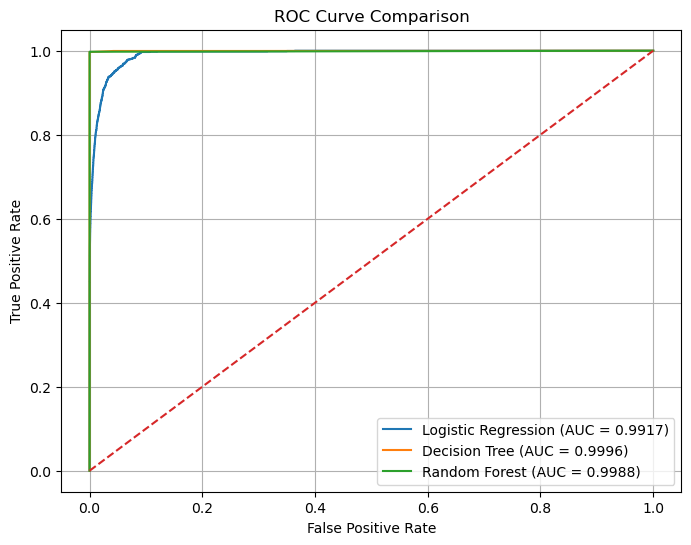

In [31]:

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs)

# Compute AUC scores
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_rf = roc_auc_score(y_test, y_probs)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()

In [32]:
print("AUC Scores:")
print(f"Logistic Regression: {auc_lr:.4f}")
print(f"Decision Tree: {auc_tree:.4f}")
print(f"Random Forest: {auc_rf:.4f}")

AUC Scores:
Logistic Regression: 0.9917
Decision Tree: 0.9996
Random Forest: 0.9988


In [33]:
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_rf = roc_auc_score(y_test, y_probs)

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Decision Tree AUC: {auc_tree:.4f}")
print(f"Random Forest AUC: {auc_rf:.4f}")

Logistic Regression AUC: 0.9917
Decision Tree AUC: 0.9996
Random Forest AUC: 0.9988


## Conclusion

- Random Forest achieved the strongest performance with near-perfect ROC-AUC.
- Logistic Regression provided strong baseline performance with interpretability.
- Fraud detection is highly imbalanced, so recall and precision are more important than accuracy.
- Lowering the classification threshold improved fraud detection (recall), highlighting the importance of threshold tuning.
- Feature engineering, particularly balance consistency, played a key role in model performance.

## Limitations

- Extremely high AUC scores may indicate potential data leakage or overly deterministic features.
- Some engineered features may not be available in real-time systems.
- Further validation with unseen or real-world data is required.